In [ ]:
!pip install unet

Files already downloaded and verified
Files already downloaded and verified


<Figure size 1500x500 with 0 Axes>

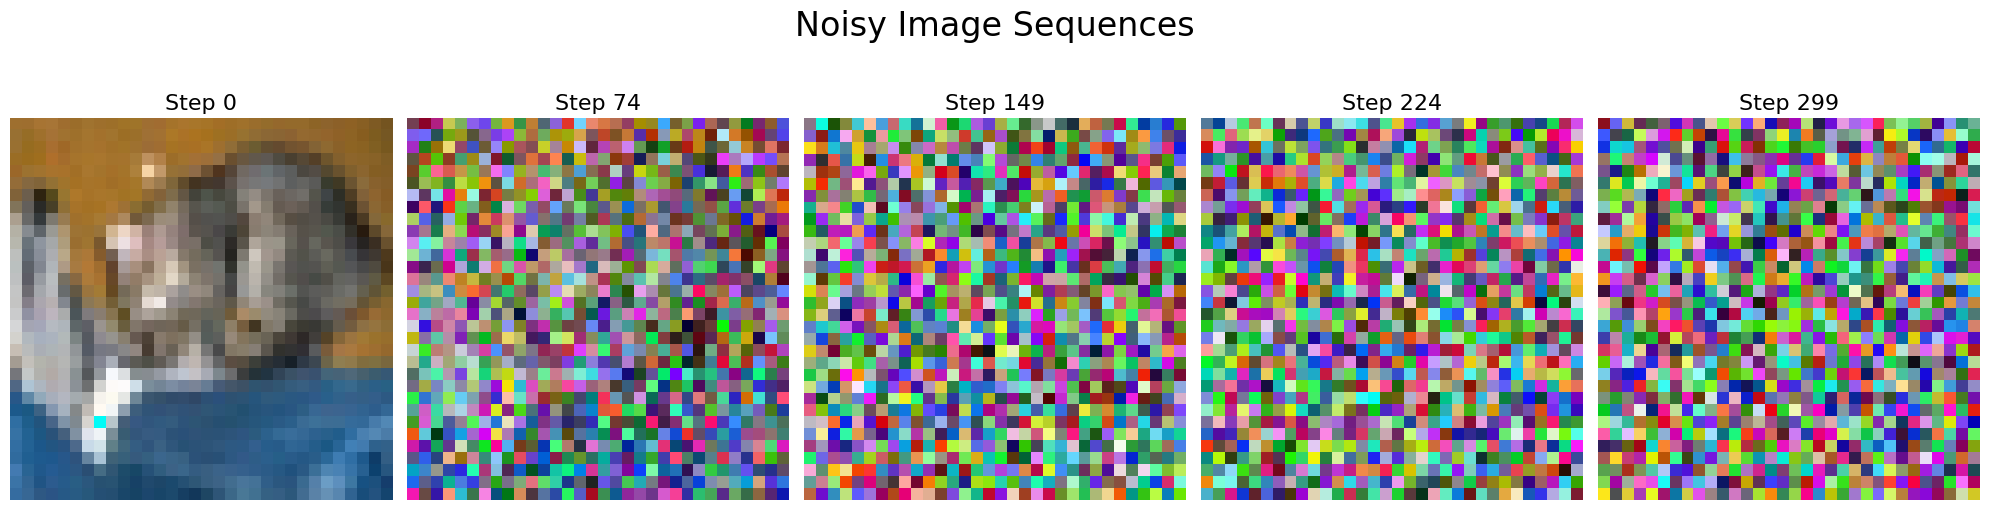

Epoch 0/100 | Loss: 1.0330
Epoch 1/100 | Loss: 0.8955
Epoch 2/100 | Loss: 0.8139
Epoch 3/100 | Loss: 0.7357
Epoch 4/100 | Loss: 0.6828
Epoch 5/100 | Loss: 0.6231
Epoch 6/100 | Loss: 0.5473
Epoch 7/100 | Loss: 0.4969
Epoch 8/100 | Loss: 0.4627
Epoch 9/100 | Loss: 0.4086
Epoch 10/100 | Loss: 0.3921
Epoch 11/100 | Loss: 0.3430
Epoch 12/100 | Loss: 0.3526
Epoch 13/100 | Loss: 0.3218
Epoch 14/100 | Loss: 0.2857
Epoch 15/100 | Loss: 0.3002
Epoch 16/100 | Loss: 0.2727
Epoch 17/100 | Loss: 0.2747
Epoch 18/100 | Loss: 0.2625
Epoch 19/100 | Loss: 0.2689
Epoch 20/100 | Loss: 0.2459
Epoch 21/100 | Loss: 0.2537
Epoch 22/100 | Loss: 0.2386
Epoch 23/100 | Loss: 0.2085
Epoch 24/100 | Loss: 0.2160
Epoch 25/100 | Loss: 0.2292
Epoch 26/100 | Loss: 0.1967
Epoch 27/100 | Loss: 0.2063
Epoch 28/100 | Loss: 0.1936
Epoch 29/100 | Loss: 0.2324
Epoch 30/100 | Loss: 0.1805
Epoch 31/100 | Loss: 0.1578
Epoch 32/100 | Loss: 0.1453
Epoch 33/100 | Loss: 0.1771
Epoch 34/100 | Loss: 0.1653
Epoch 35/100 | Loss: 0.1690
Ep

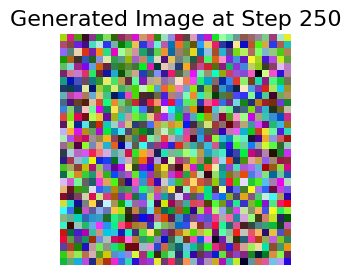

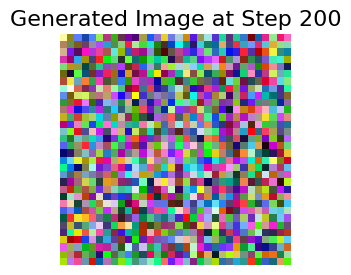

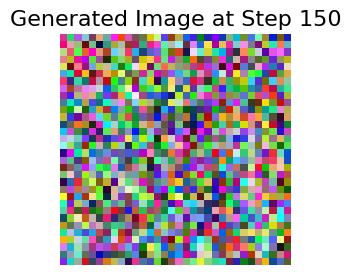

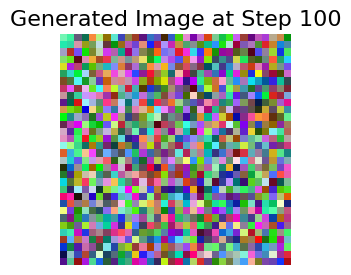

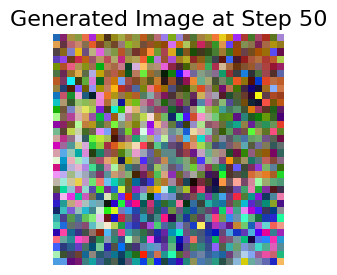

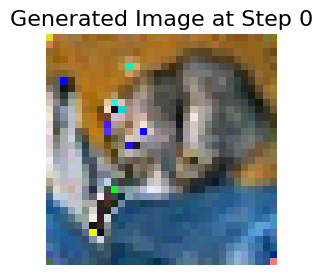

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import math
from unet import UNet

device = torch.device("cuda:0")

def fetch_sample_image():
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((32, 32)),
    ])
    dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
    image, _ = dataset[0]
    image_pil = transforms.ToPILImage()(image)  # Convert to PIL image
    return image_pil

sample_image = fetch_sample_image()
transformation = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda t: (t * 2) - 1),
])

def reverse_transformation(image):
    transform = transforms.Compose([
        transforms.Lambda(lambda t: (t + 1) / 2),
        transforms.Lambda(lambda t: t.permute(1, 2, 0)),
        transforms.Lambda(lambda t: t * 255.),
        transforms.Lambda(lambda t: t.cpu().numpy().astype(np.uint8)),
        transforms.ToPILImage(),
    ])
    return transform(image)

class DiffusionModel:
    def __init__(self, start_val=0.0001, end_val=0.02, steps=300):
        self.start_val = start_val
        self.end_val = end_val
        self.steps = steps
        self.beta_vals = torch.linspace(start_val, end_val, steps)
        self.alpha_vals = 1 - self.beta_vals
        self.alpha_cumprod_vals = torch.cumprod(self.alpha_vals, axis=0)

    def forward(self, input_data, step, device):
        noise = torch.randn_like(input_data)
        alpha_cumprod_step = self.get_value_from_list(self.alpha_cumprod_vals.sqrt(), step, input_data.shape)
        sqrt_diff_alpha_cumprod = self.get_value_from_list(torch.sqrt(1. - self.alpha_cumprod_vals), step, input_data.shape)
        mean = alpha_cumprod_step.to(device) * input_data.to(device)
        variance = sqrt_diff_alpha_cumprod.to(device) * noise.to(device)
        return mean + variance, noise.to(device)

    @torch.no_grad()
    def backward(self, input_data, step, model, **kwargs):
        beta_step = self.get_value_from_list(self.beta_vals, step, input_data.shape)
        sqrt_diff_alpha_cumprod_step = self.get_value_from_list(torch.sqrt(1. - self.alpha_cumprod_vals), step, input_data.shape)
        sqrt_recip_alpha_step = self.get_value_from_list(torch.sqrt(1.0 / self.alpha_vals), step, input_data.shape)
        mean = sqrt_recip_alpha_step * (input_data - beta_step * model(input_data, step, **kwargs) / sqrt_diff_alpha_cumprod_step)
        posterior_variance_step = beta_step
        if step == 0:
            return mean
        else:
            noise = torch.randn_like(input_data)
            variance = torch.sqrt(posterior_variance_step) * noise
            return mean + variance

    @staticmethod
    def get_value_from_list(values, step, input_shape):
        batch_size = step.shape[0]
        result = values.gather(-1, step.cpu())
        return result.reshape(batch_size, *((1,) * (len(input_shape) - 1))).to(step.device)

IMAGE_DIM = (32, 32)

sample_image = fetch_sample_image()
transformation = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda t: (t * 2) - 1),
])

tensor_image = transformation(sample_image)
diffusion_model = DiffusionModel()

DISPLAY_COUNT = 5
tensor_image_batch = torch.stack([tensor_image] * DISPLAY_COUNT)
steps = torch.linspace(0, diffusion_model.steps - 1, DISPLAY_COUNT).long()
noisy_image_batch, _ = diffusion_model.forward(tensor_image_batch, steps, device)

# Display the noisy image batch horizontally
plt.figure(figsize=(15, 5))  # Adjust the height of the figure
f, ax = plt.subplots(1, DISPLAY_COUNT, figsize=(20, 5))  # 1 row, DISPLAY_COUNT columns

for idx, image in enumerate(noisy_image_batch):
    ax[idx].imshow(reverse_transformation(image))
    ax[idx].set_title(f"Step {steps[idx].item()}", fontsize=16)
    ax[idx].axis('off')  # Hide axes for a cleaner look

plt.suptitle("Noisy Image Sequences", fontsize=24, y=1.05)
plt.tight_layout()
plt.show()

class PositionalEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class NetworkBlock(nn.Module):
    def __init__(self, channels_in, channels_out, time_embedding_dim, has_labels, filter_count=3, downsample=True):
        super().__init__()
        self.time_embedding_dim = time_embedding_dim
        self.time_embedding = PositionalEmbeddings(time_embedding_dim)
        self.has_labels = has_labels
        if has_labels:
            self.label_mlp = nn.Linear(1, channels_out)
        self.downsample = downsample
        if downsample:
            self.conv1 = nn.Conv2d(channels_in, channels_out, filter_count, padding=1)
            self.final = nn.Conv2d(channels_out, channels_out, 4, 2, 1)
        else:
            self.conv1 = nn.Conv2d(2 * channels_in, channels_out, filter_count, padding=1)
            self.final = nn.ConvTranspose2d(channels_out, channels_out, 4, 2, 1)
        self.batch_norm1 = nn.BatchNorm2d(channels_out)
        self.batch_norm2 = nn.BatchNorm2d(channels_out)
        self.conv2 = nn.Conv2d(channels_out, channels_out, 3, padding=1)
        self.time_mlp = nn.Linear(time_embedding_dim, channels_out)
        self.relu = nn.ReLU()

    def forward(self, x, t, **kwargs):
        out = self.batch_norm1(self.relu(self.conv1(x)))
        time_embedding = self.relu(self.time_mlp(self.time_embedding(t)))
        out = out + time_embedding[(..., ) + (None, ) * 2]
        if self.has_labels:
            label = kwargs.get('labels')
            label_embedding = self.relu(self.label_mlp(label))
            out = out + label_embedding[(..., ) + (None, ) * 2]
        out = self.batch_norm2(self.relu(self.conv2(out)))
        return self.final(out)

class UNetModel(nn.Module):
    def __init__(self, img_channels=3, time_embedding_dim=128, has_labels=False, channel_sequence=(64, 128, 256, 512, 1024)):
        super().__init__()
        self.time_embedding_dim = time_embedding_dim
        self.downsampling = nn.ModuleList([NetworkBlock(ch_in, ch_out, time_embedding_dim, has_labels) for ch_in, ch_out in zip(channel_sequence, channel_sequence[1:])])
        self.upsampling = nn.ModuleList([NetworkBlock(ch_in, ch_out, time_embedding_dim, has_labels, downsample=False) for ch_in, ch_out in zip(channel_sequence[::-1], channel_sequence[::-1][1:])])
        self.conv1 = nn.Conv2d(img_channels, channel_sequence[0], 3, padding=1)
        self.conv2 = nn.Conv2d(channel_sequence[0], img_channels, 1)

    def forward(self, x, t, **kwargs):
        residuals = []
        out = self.conv1(x)
        for downsample in self.downsampling:
            out = downsample(out, t, **kwargs)
            residuals.append(out)
        for upsample, residual in zip(self.upsampling, reversed(residuals)):
            out = upsample(torch.cat((out, residual), dim=1), t, **kwargs)
        return self.conv2(out)

EPOCHS = 100
LOG_INTERVAL = 400
LEARNING_RATE = 0.001
BATCH_SIZE = 128
VERBOSE = True

unet_model = UNetModel(has_labels=False)
unet_model.to(device)
optimizer = optim.Adam(unet_model.parameters(), lr=LEARNING_RATE)

for epoch in range(EPOCHS):
    epoch_loss = []
    batch = torch.stack([tensor_image] * BATCH_SIZE)
    t = torch.randint(0, diffusion_model.steps, (BATCH_SIZE,)).long().to(device)
    batch_noisy, noise = diffusion_model.forward(batch, t, device)
    predicted_noise = unet_model(batch_noisy, t)
    optimizer.zero_grad()
    loss = torch.nn.functional.mse_loss(noise, predicted_noise)
    epoch_loss.append(loss.item())
    loss.backward()
    optimizer.step()
    if epoch % 1 == 0:
        print(f"Epoch {epoch}/{EPOCHS} | Loss: {np.mean(epoch_loss):.4f}")

with torch.no_grad():
    generated_img = torch.randn((1, 3) + IMAGE_DIM).to(device)
    for i in reversed(range(diffusion_model.steps)):
        t = torch.full((1,), i, dtype=torch.long, device=device)
        generated_img = diffusion_model.backward(generated_img, t, unet_model.eval())
        if i % 50 == 0:
            plt.figure(figsize=(3, 3))
            plt.imshow(reverse_transformation(generated_img[0]))
            plt.axis('off')
            plt.title(f"Generated Image at Step {i}", fontsize=16)
            plt.show()


Training with Steps: 50, Noise Level: 0.01
Training with Steps: 50, Noise Level: 0.05


<ipython-input-15-971fbb865be7>:30: RuntimeWarning: invalid value encountered in cast
  transforms.Lambda(lambda t: t.cpu().numpy().astype(np.uint8)),


Training with Steps: 50, Noise Level: 0.1
Training with Steps: 100, Noise Level: 0.01
Training with Steps: 100, Noise Level: 0.05
Training with Steps: 100, Noise Level: 0.1


<ipython-input-15-971fbb865be7>:30: RuntimeWarning: invalid value encountered in cast
  transforms.Lambda(lambda t: t.cpu().numpy().astype(np.uint8)),


Training with Steps: 300, Noise Level: 0.01
Training with Steps: 300, Noise Level: 0.05
Training with Steps: 300, Noise Level: 0.1


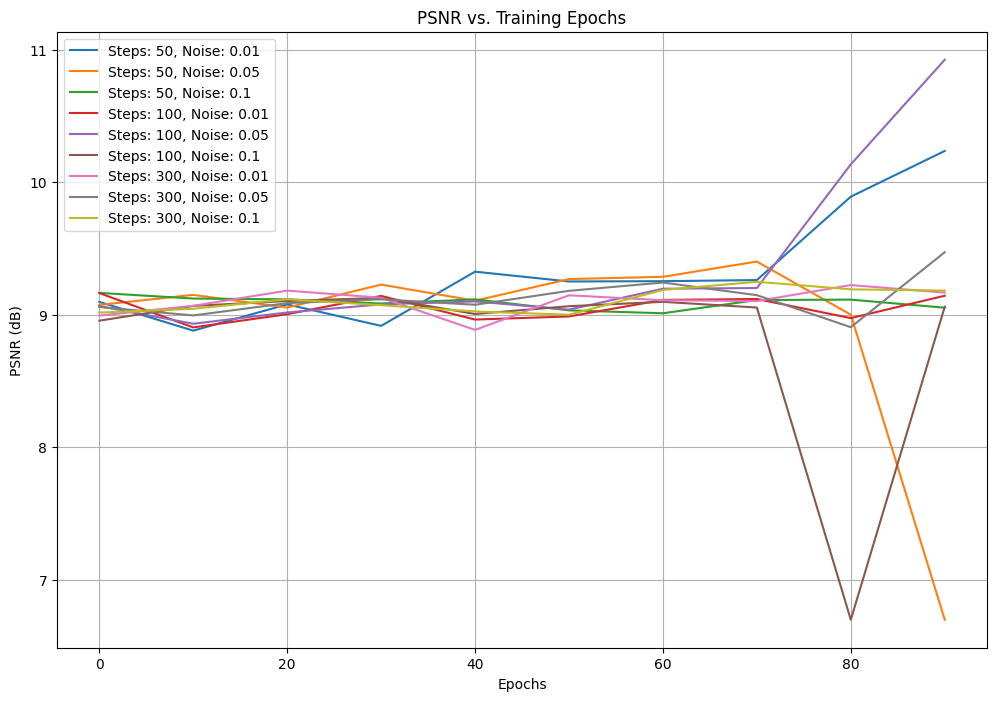

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import math
from unet import UNet
from sklearn.metrics import mean_squared_error

device = torch.device("cuda:0")

def fetch_sample_image():
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((32, 32)),
    ])
    dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
    image, _ = dataset[0]
    image_pil = transforms.ToPILImage()(image)  # Convert to PIL image
    return image_pil

# Reverse transformations for visualization (returns NumPy array)
def reverse_transformation(image):
    transform = transforms.Compose([
        transforms.Lambda(lambda t: (t + 1) / 2),
        transforms.Lambda(lambda t: t.permute(1, 2, 0)),
        transforms.Lambda(lambda t: t * 255.),
        transforms.Lambda(lambda t: t.cpu().numpy().astype(np.uint8)),
    ])
    return transform(image)

# PSNR function to evaluate the quality of generated images
def calculate_psnr(original, generated):
    mse = mean_squared_error(original.flatten(), generated.flatten())
    return 10 * np.log10(255.0 ** 2 / mse)

# Modify DiffusionModel to handle different step sizes and noise levels
class DiffusionModel:
    def __init__(self, start_val=0.0001, end_val=0.02, steps=300):
        self.start_val = start_val
        self.end_val = end_val
        self.steps = steps
        self.beta_vals = torch.linspace(start_val, end_val, steps)
        self.alpha_vals = 1 - self.beta_vals
        self.alpha_cumprod_vals = torch.cumprod(self.alpha_vals, axis=0)

    def forward(self, input_data, step, device):
        noise = torch.randn_like(input_data)
        alpha_cumprod_step = self.get_value_from_list(self.alpha_cumprod_vals.sqrt(), step, input_data.shape)
        sqrt_diff_alpha_cumprod = self.get_value_from_list(torch.sqrt(1. - self.alpha_cumprod_vals), step, input_data.shape)
        mean = alpha_cumprod_step.to(device) * input_data.to(device)
        variance = sqrt_diff_alpha_cumprod.to(device) * noise.to(device)
        return mean + variance, noise.to(device)

    @torch.no_grad()
    def backward(self, input_data, step, model, **kwargs):
        beta_step = self.get_value_from_list(self.beta_vals, step, input_data.shape)
        sqrt_diff_alpha_cumprod_step = self.get_value_from_list(torch.sqrt(1. - self.alpha_cumprod_vals), step, input_data.shape)
        sqrt_recip_alpha_step = self.get_value_from_list(torch.sqrt(1.0 / self.alpha_vals), step, input_data.shape)
        mean = sqrt_recip_alpha_step * (input_data - beta_step * model(input_data, step, **kwargs) / sqrt_diff_alpha_cumprod_step)
        posterior_variance_step = beta_step
        if step == 0:
            return mean
        else:
            noise = torch.randn_like(input_data)
            variance = torch.sqrt(posterior_variance_step) * noise
            return mean + variance

    @staticmethod
    def get_value_from_list(values, step, input_shape):
        batch_size = step.shape[0]
        result = values.gather(-1, step.cpu())
        return result.reshape(batch_size, *((1,) * (len(input_shape) - 1))).to(step.device)

# Training and Testing Loop
steps_list = [50, 100, 300]
noise_levels = [0.01, 0.05, 0.1]

# Store results for plotting
psnr_results = {}

for steps in steps_list:
    for noise_level in noise_levels:
        print(f"Training with Steps: {steps}, Noise Level: {noise_level}")

        # Create new DiffusionModel and UNetModel instances
        diffusion_model = DiffusionModel(steps=steps)
        unet_model = UNetModel(has_labels=False)
        unet_model.to(device)
        optimizer = optim.Adam(unet_model.parameters(), lr=0.001)

        # Track PSNR during training
        psnr_values = []

        # Training
        for epoch in range(100):
            epoch_loss = []
            batch = torch.stack([tensor_image] * 128)
            t = torch.randint(0, diffusion_model.steps, (128,)).long().to(device)
            batch_noisy, noise = diffusion_model.forward(batch, t, device)
            predicted_noise = unet_model(batch_noisy, t)
            optimizer.zero_grad()
            loss = torch.nn.functional.mse_loss(noise, predicted_noise)
            epoch_loss.append(loss.item())
            loss.backward()
            optimizer.step()

            # Every 10 epochs, calculate PSNR on the generated image
            if epoch % 10 == 0:
                with torch.no_grad():
                    generated_img = torch.randn((1, 3) + (32, 32)).to(device)
                    for i in reversed(range(diffusion_model.steps)):
                        t = torch.full((1,), i, dtype=torch.long, device=device)
                        generated_img = diffusion_model.backward(generated_img, t, unet_model.eval())
                        if i % steps == 0:
                            generated_img_np = reverse_transformation(generated_img[0])
                            original_img_np = reverse_transformation(tensor_image)
                            psnr = calculate_psnr(original_img_np, generated_img_np)
                            psnr_values.append(psnr)

        # Store PSNR results for plotting
        psnr_results[(steps, noise_level)] = psnr_values

# Plotting results
plt.figure(figsize=(12, 8))

for (steps, noise_level), psnr_values in psnr_results.items():
    plt.plot(range(0, 100, 10), psnr_values, label=f"Steps: {steps}, Noise: {noise_level}")

plt.title("PSNR vs. Training Epochs")
plt.xlabel("Epochs")
plt.ylabel("PSNR (dB)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import PIL
import urllib
import math
from unet import UNet

# Constants and Hyperparameters
DEVICE = torch.device("cuda:0")
IMAGE_SHAPE = (32, 32)
NOISE_SCHEDULE_START = 0.0001
NOISE_SCHEDULE_END = 0.02
TIMESTEPS = 300
BATCH_SIZE = 128
EPOCHS = 3
LEARNING_RATE = 0.001
PRINT_FREQUENCY = 1
NUM_CLASSES = 10
NUM_DISPLAY_IMAGES = 20

# Transformations
TRANSFORM = transforms.Compose([
    transforms.Resize(IMAGE_SHAPE),  # Resize the input image
    transforms.ToTensor(),  # Convert to torch tensor (scales data into [0,1])
    transforms.Lambda(lambda t: (t * 2) - 1),  # Scale data between [-1, 1]
])

REVERSE_TRANSFORM = transforms.Compose([
    transforms.Lambda(lambda t: (t + 1) / 2),  # Scale data between [0,1]
    transforms.Lambda(lambda t: t.permute(1, 2, 0)),  # CHW to HWC
    transforms.Lambda(lambda t: t * 255.),  # Scale data between [0.,255.]
    transforms.Lambda(lambda t: t.cpu().numpy().astype(np.uint8)),  # Convert into an uint8 numpy array
    transforms.ToPILImage(),  # Convert to PIL image
])

# Diffusion Model Class
class DiffusionModel:
    def __init__(self, start_schedule=NOISE_SCHEDULE_START, end_schedule=NOISE_SCHEDULE_END, timesteps=TIMESTEPS):
        self.start_schedule = start_schedule
        self.end_schedule = end_schedule
        self.timesteps = timesteps
        self.betas = torch.linspace(start_schedule, end_schedule, timesteps)
        self.alphas = 1 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, axis=0)

    def forward(self, x_0, t, device):
        noise = torch.randn_like(x_0)
        sqrt_alphas_cumprod_t = self.get_index_from_list(self.alphas_cumprod.sqrt(), t, x_0.shape)
        sqrt_one_minus_alphas_cumprod_t = self.get_index_from_list(torch.sqrt(1. - self.alphas_cumprod), t, x_0.shape)

        mean = sqrt_alphas_cumprod_t.to(device) * x_0.to(device)
        variance = sqrt_one_minus_alphas_cumprod_t.to(device) * noise.to(device)

        return mean + variance, noise.to(device)

    @torch.no_grad()
    def backward(self, x, t, model, **kwargs):
        betas_t = self.get_index_from_list(self.betas, t, x.shape)
        sqrt_one_minus_alphas_cumprod_t = self.get_index_from_list(torch.sqrt(1. - self.alphas_cumprod), t, x.shape)
        sqrt_recip_alphas_t = self.get_index_from_list(torch.sqrt(1.0 / self.alphas), t, x.shape)
        mean = sqrt_recip_alphas_t * (x - betas_t * model(x, t, **kwargs) / sqrt_one_minus_alphas_cumprod_t)
        posterior_variance_t = betas_t

        if t == 0:
            return mean
        else:
            noise = torch.randn_like(x)
            variance = torch.sqrt(posterior_variance_t) * noise
            return mean + variance

    @staticmethod
    def get_index_from_list(values, t, x_shape):
        batch_size = t.shape[0]
        result = values.gather(-1, t.cpu())
        return result.reshape(batch_size, *((1,) * (len(x_shape) - 1))).to(t.device)


# U-Net Network Class
class Block(nn.Module):
    def __init__(self, channels_in, channels_out, time_embedding_dims, labels, num_filters=3, downsample=True):
        super().__init__()

        self.time_embedding_dims = time_embedding_dims
        self.time_embedding = SinusoidalPositionEmbeddings(time_embedding_dims)
        self.labels = labels
        if labels:
            self.label_mlp = nn.Linear(1, channels_out)

        self.downsample = downsample
        if downsample:
            self.conv1 = nn.Conv2d(channels_in, channels_out, num_filters, padding=1)
            self.final = nn.Conv2d(channels_out, channels_out, 4, 2, 1)
        else:
            self.conv1 = nn.Conv2d(2 * channels_in, channels_out, num_filters, padding=1)
            self.final = nn.ConvTranspose2d(channels_out, channels_out, 4, 2, 1)

        self.bnorm1 = nn.BatchNorm2d(channels_out)
        self.bnorm2 = nn.BatchNorm2d(channels_out)

        self.conv2 = nn.Conv2d(channels_out, channels_out, 3, padding=1)
        self.time_mlp = nn.Linear(time_embedding_dims, channels_out)
        self.relu = nn.ReLU()

    def forward(self, x, t, **kwargs):
        o = self.bnorm1(self.relu(self.conv1(x)))
        o_time = self.relu(self.time_mlp(self.time_embedding(t)))
        o = o + o_time[(..., ) + (None, ) * 2]
        if self.labels:
            label = kwargs.get('labels')
            o_label = self.relu(self.label_mlp(label))
            o = o + o_label[(..., ) + (None, ) * 2]

        o = self.bnorm2(self.relu(self.conv2(o)))
        return self.final(o)


# U-Net Model Class
class UNet(nn.Module):
    def __init__(self, img_channels=3, time_embedding_dims=128, labels=False, sequence_channels=(64, 128, 256, 512, 1024)):
        super().__init__()
        self.time_embedding_dims = time_embedding_dims
        sequence_channels_rev = reversed(sequence_channels)

        self.downsampling = nn.ModuleList([Block(channels_in, channels_out, time_embedding_dims, labels) for channels_in, channels_out in zip(sequence_channels, sequence_channels[1:])])
        self.upsampling = nn.ModuleList([Block(channels_in, channels_out, time_embedding_dims, labels, downsample=False) for channels_in, channels_out in zip(sequence_channels[::-1], sequence_channels[::-1][1:])])
        self.conv1 = nn.Conv2d(img_channels, sequence_channels[0], 3, padding=1)
        self.conv2 = nn.Conv2d(sequence_channels[0], img_channels, 1)

    def forward(self, x, t, **kwargs):
        residuals = []
        o = self.conv1(x)
        for ds in self.downsampling:
            o = ds(o, t, **kwargs)
            residuals.append(o)
        for us, res in zip(self.upsampling, reversed(residuals)):
            o = us(torch.cat((o, res), dim=1), t, **kwargs)

        return self.conv2(o)


# Sinusoidal Position Embedding Class
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings


# Function to get CIFAR-10 image
def get_cifar_image():
    trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=TRANSFORM)
    return trainset[0][0]

# Function to plot noisy image distribution
def plot_noisy_image_distribution(noise, predicted_noise):
    plt.hist(noise.cpu().numpy().flatten(), density=True, alpha=0.8, label="ground truth noise")
    plt.hist(predicted_noise.cpu().numpy().flatten(), density=True, alpha=0.8, label="predicted noise")
    plt.legend()
    plt.show()


# Training Loop
def train_diffusion_model():
    device = DEVICE
    model = UNet(labels=False)
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=TRANSFORM)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=8, drop_last=True)

    diffusion_model = DiffusionModel()

    for epoch in range(EPOCHS):
        mean_epoch_loss = []
        for batch, _ in trainloader:
            batch = batch.to(device)
            t = torch.randint(0, diffusion_model.timesteps, (BATCH_SIZE,)).long().to(device)

            batch_noisy, noise = diffusion_model.forward(batch, t, device)
            predicted_noise = model(batch_noisy, t)

            optimizer.zero_grad()
            loss = torch.nn.functional.mse_loss(noise, predicted_noise)
            mean_epoch_loss.append(loss.item())
            loss.backward()
            optimizer.step()

        if epoch % PRINT_FREQUENCY == 0:
            print(f"Epoch: {epoch} | Train Loss {np.mean(mean_epoch_loss)}")


# Run training
train_diffusion_model()


Files already downloaded and verified


/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch: 0 | Train Loss 0.12607267688100154
Epoch: 1 | Train Loss 0.07687858127248592
Epoch: 2 | Train Loss 0.07324802287113973


In [ ]:
# Training parameters
BATCH_SIZE = 256
NO_EPOCHS = 1
PRINT_FREQUENCY = 1
LR = 0.001
VERBOSE = False

# Initialize UNet model and optimizer
unet = UNet(labels=True)
unet.to(device)
optimizer = torch.optim.Adam(unet.parameters(), lr=LR)

# Load CIFAR-10 dataset
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=8, drop_last=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=8, drop_last=True)

# Training loop
for epoch in range(NO_EPOCHS):
    mean_epoch_loss = []
    mean_epoch_loss_val = []

    # Training phase
    for batch, label in trainloader:
        t = torch.randint(0, diffusion_model.timesteps, (BATCH_SIZE,)).long().to(device)
        batch = batch.to(device)

        # Apply forward diffusion to create noisy images
        batch_noisy, noise = diffusion_model.forward(batch, t, device)

        # Predict the noise using the UNet model
        predicted_noise = unet(batch_noisy, t, labels=label.reshape(-1, 1).float().to(device))

        # Calculate loss and update model parameters
        optimizer.zero_grad()
        loss = torch.nn.functional.mse_loss(noise, predicted_noise)
        mean_epoch_loss.append(loss.item())
        loss.backward()
        optimizer.step()

    # Validation phase
    for batch, label in testloader:
        t = torch.randint(0, diffusion_model.timesteps, (BATCH_SIZE,)).long().to(device)
        batch = batch.to(device)

        batch_noisy, noise = diffusion_model.forward(batch, t, device)
        predicted_noise = unet(batch_noisy, t, labels=label.reshape(-1, 1).float().to(device))

        loss = torch.nn.functional.mse_loss(noise, predicted_noise)
        mean_epoch_loss_val.append(loss.item())

    # Print progress and save model
    if epoch % PRINT_FREQUENCY == 0:
        print('---')
        print(f"Epoch: {epoch} | Train Loss {np.mean(mean_epoch_loss)} | Val Loss {np.mean(mean_epoch_loss_val)}")

        if VERBOSE:
            with torch.no_grad():
                plot_noise_prediction(noise[0], predicted_noise[0])
                plot_noise_distribution(noise, predicted_noise)

        # Save the model weights after each epoch
        torch.save(unet.state_dict(), f"epoch_{epoch}.pth")

# Now, generate class-conditioned images using the trained model
CLASSES = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
NUM_CLASSES = len(CLASSES)
NUM_DISPLAY_IMAGES = 20

# Set random seed for reproducibility
torch.manual_seed(16)

# Create the figure for displaying generated images
plt.figure(figsize=(15, 15))
f, ax = plt.subplots(NUM_CLASSES, NUM_DISPLAY_IMAGES, figsize=(100, 100))

# Loop through each class and generate images conditioned on that class
for c in range(NUM_CLASSES):
    imgs = torch.randn((NUM_DISPLAY_IMAGES, 3) + IMAGE_SHAPE).to(device)  # Initial noise images

    # Apply reverse diffusion process for each image
    for i in reversed(range(diffusion_model.timesteps)):
        t = torch.full((1,), i, dtype=torch.long, device=device)
        labels = torch.tensor([c] * NUM_DISPLAY_IMAGES).resize(NUM_DISPLAY_IMAGES, 1).float().to(device)
        imgs = diffusion_model.backward(x=imgs, t=t, model=unet.eval().to(device), labels=labels)

    # Plot the generated images for the current class
    for idx, img in enumerate(imgs):
        ax[c][idx].imshow(reverse_transform(img))
        ax[c][idx].set_title(f"Class: {CLASSES[c]}", fontsize=10)

# Show the generated images
plt.show()


Files already downloaded and verified
Files already downloaded and verified
---
Epoch: 0 | Train Loss 0.17992163801040406 | Val Loss 0.09002599903406241


/usr/local/lib/python3.10/dist-packages/torch/_tensor.py:955: UserWarning: non-inplace resize is deprecated
  warnings.warn("non-inplace resize is deprecated")


<Figure size 1500x1500 with 0 Axes>

In [ ]:
from torchvision import transforms
from torchvision.transforms import ToPILImage

# Define the InceptionV3 model for IS calculation
inception_model = models.inception_v3(pretrained=True, transform_input=False)
inception_model = inception_model.to(device)
inception_model.eval()

# Define the transform to resize images to the expected input size of InceptionV3
resize_transform = transforms.Compose([
    transforms.Resize((299, 299)),  # Resize images to 299x299 pixels
    transforms.ToTensor(),          # Convert to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize to the same distribution as ImageNet
])

# Function to calculate Inception Score
def calculate_inception_score(images, batch_size=50):
    """
    Calculate Inception Score for generated images.
    images: Tensor of shape (batch_size, 3, height, width)
    """
    n = images.shape[0]
    pred = []

    # Initialize ToPILImage to convert tensor to PIL image
    to_pil = ToPILImage()

    # Split the batch into smaller chunks for memory efficiency
    for i in range(0, n, batch_size):
        batch = images[i:i + batch_size]

        # Convert each tensor to PIL image and apply resize_transform
        batch_resized = torch.stack([resize_transform(to_pil(img)) for img in batch])

        with torch.no_grad():
            output = inception_model(batch_resized.to(device))
            pred.append(F.softmax(output, dim=1).cpu().numpy())

    # Concatenate predictions
    pred = np.concatenate(pred, axis=0)

    # Calculate the marginal distribution p(y)
    p_y = np.mean(pred, axis=0)

    # Calculate the conditional distributions p(y|x) and compute KL divergence for each image
    scores = []
    for i in range(n):
        p_y_x = pred[i]
        kl_div = entropy(p_y_x, p_y)
        scores.append(np.exp(kl_div))

    # Return the mean and std of Inception Scores
    return np.mean(scores), np.std(scores)

# Now calculate IS for generated images for each class

CLASSES = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
NUM_CLASSES = len(CLASSES)
NUM_DISPLAY_IMAGES = 20

# Set random seed for reproducibility
torch.manual_seed(16)

# Inception score per class
inception_scores = {}

# Loop through each class and generate images conditioned on that class
for c in range(NUM_CLASSES):
    imgs = torch.randn((NUM_DISPLAY_IMAGES, 3) + IMAGE_SHAPE).to(device)  # Initial noise images

    # Apply reverse diffusion process for each image
    for i in reversed(range(diffusion_model.timesteps)):
        t = torch.full((1,), i, dtype=torch.long, device=device)
        labels = torch.tensor([c] * NUM_DISPLAY_IMAGES).resize(NUM_DISPLAY_IMAGES, 1).float().to(device)
        imgs = diffusion_model.backward(x=imgs, t=t, model=unet.eval().to(device), labels=labels)

    # Calculate Inception Score for the current class
    mean_is, std_is = calculate_inception_score(imgs)
    inception_scores[CLASSES[c]] = (mean_is, std_is)

# Print Inception Scores for each class
for class_name, (mean_is, std_is) in inception_scores.items():
    print(f"Inception Score for {class_name}: Mean = {mean_is:.3f}, Std = {std_is:.3f}")


Inception Score for plane: Mean = 1.808, Std = 0.687
Inception Score for car: Mean = 1.531, Std = 0.444
Inception Score for bird: Mean = 1.644, Std = 0.547
Inception Score for cat: Mean = 1.678, Std = 0.948
Inception Score for deer: Mean = 1.659, Std = 0.866
Inception Score for dog: Mean = 1.625, Std = 0.405
Inception Score for frog: Mean = 1.566, Std = 0.528
Inception Score for horse: Mean = 1.614, Std = 0.455
Inception Score for ship: Mean = 1.743, Std = 0.532
Inception Score for truck: Mean = 1.507, Std = 0.261
